# Sydney Housing Price Prediction and Decision Support System
**SIT720 Task 8.1D – Machine Learning Mini Project**

Sections:
1. Introduction
2. Dataset and Data Quality
3. Exploratory Data Analysis
4. Important Original Variables
5. Feature Engineering
6. Model Development
7. Cross-Validation and Model Comparison
8. Final Holdout Evaluation
9. Error Analysis
10. Gradient Boosting vs ChatGPT vs Human
11. Streamlit Application
12. Limitations, Ethics and Conclusion

Numbers quoted in the text come from the outputs below (random seed 42).

In [1]:
import hashlib
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import sklearn
from scipy import stats
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# The notebook lives in notebooks/, so the project root is one level up.
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))
from src.features import (TARGET, SUBURBS, ORIGINAL_NUMERIC, ORIGINAL_CATEGORICAL, ENGINEERED_IN_CSV,
                          MODEL_INPUTS, MODEL_CATEGORICAL, ENGINEERED_NUMERIC, FLAGS,
                          HousingFeatures, GroupMedianImputer, GroupMedianRegressor)

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
np.random.seed(SEED)

DATA_PATH = ROOT / "data" / "sydney_housing_final.csv"
EXPECTED_SHA256 = "0253162a2587e654cb30fcb4b47f1501034353cb2f94941ff3c29540982283ea"
FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
SUBURB_ORDER = ["Blacktown", "Parramatta", "Mosman"]
TYPE_ORDER = ["House", "Townhouse", "Unit"]
COLOURS = {"Blacktown": "#1b9e77", "Parramatta": "#d95f02", "Mosman": "#7570b3"}


def aud(x, pos=None):
    # Short dollar labels for plots, e.g. $650k or $1.2M
    if abs(x) >= 1e6:
        return f"${x / 1e6:.1f}M"
    return f"${x / 1e3:.0f}k"


AUD_FMT = mtick.FuncFormatter(aud)


def dollar_axis(axis):
    axis.set_major_formatter(AUD_FMT)
    axis.set_minor_formatter(mtick.NullFormatter())


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)


def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

## 1. Introduction

The aim is to estimate the sale price (AUD) of a house, townhouse or unit from its listing details, as decision support for a real-estate agent. This is a regression problem, and the tool is not meant to replace a professional valuation.

I chose three suburbs with very different housing markets:
- **Blacktown** (Western Sydney): mostly detached houses on large blocks at lower prices.
- **Parramatta** (Sydney's second CBD): mostly apartments, with some older houses.
- **Mosman** (Lower North Shore): a prestige harbour-side suburb with some very expensive houses.

I expected location, property type and size to be the main price drivers, and land to matter differently in each suburb.

## 2. Dataset and Data Quality

The dataset contains 105 sold-property records from Blacktown, Parramatta and Mosman (35 each). The records were initially assembled from public property sources (realestate.com.au sold listings) and were then manually reviewed against the recorded source pages. I also ran duplicate, plausibility, missing-value and consistency checks. Unsupported or conflicting values were left missing rather than invented, and genuine extreme sales were kept.

The source log `data/property_sources.csv` records the source URL, the original collection method and whether the price and date were also matched on the individual listing page.

In [2]:
# Stop if the canonical dataset has been changed in any way.
assert file_sha256(DATA_PATH) == EXPECTED_SHA256

raw = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
assert raw.shape == (105, 29)
assert raw["property_id"].is_unique and raw["address"].is_unique
assert raw[TARGET].notna().all()
assert set(raw["suburb"]) == SUBURBS
assert (raw["suburb"].value_counts() == 35).all()

# Basic plausibility checks (the data is not changed, only checked).
assert raw["sale_date"].notna().all()
assert not raw.duplicated(["address", "sale_date", TARGET]).any()
assert raw["bedrooms"].between(1, 10).all() and raw["bathrooms"].between(1, 10).all()
assert raw["car_spaces"].dropna().between(0, 10).all()
assert raw.loc[raw["property_type"] == "Unit", "land_size_sqm"].isna().all()  # unit land is structurally missing

print("Sale dates:", raw["sale_date"].min().date(), "to", raw["sale_date"].max().date())
pd.crosstab(raw["suburb"], raw["property_type"], margins=True).loc[SUBURB_ORDER + ["All"]]

Sale dates: 2025-09-20 to 2026-09-11


property_type,House,Townhouse,Unit,All
suburb,,,,
Blacktown,24,2,9,35
Parramatta,11,1,23,35
Mosman,13,1,21,35
All,48,4,53,105


In [3]:
sources = pd.read_csv(ROOT / "data" / "property_sources.csv")
merged = raw.merge(sources[["address", "sale_price", "detail_price_date_matched", "manual_review_completed"]],
                   on="address", suffixes=("", "_source"))

print("Every price matches the source log:", (merged[TARGET] == merged["sale_price_source"]).all())
print("Manually reviewed records:", merged["manual_review_completed"].sum(), "of", len(merged))
print("Price and date also matched on the listing detail page:", merged["detail_price_date_matched"].sum(), "of", len(merged))

# Kept for the error analysis later on.
unmatched_ids = set(merged.loc[~merged["detail_price_date_matched"], "property_id"])

Every price matches the source log: True
Manually reviewed records: 105 of 105
Price and date also matched on the listing detail page: 75 of 105


Price and date could not be matched on the individual listing page for 30 records, mostly Mosman houses (only 3 of 13 matched). These sales were kept because there is no evidence the values are wrong, but I flag them again in the error analysis.

### Missing values

Missing values: {'car_spaces': 1, 'land_size_sqm': 56, 'building_size_sqm': 57}


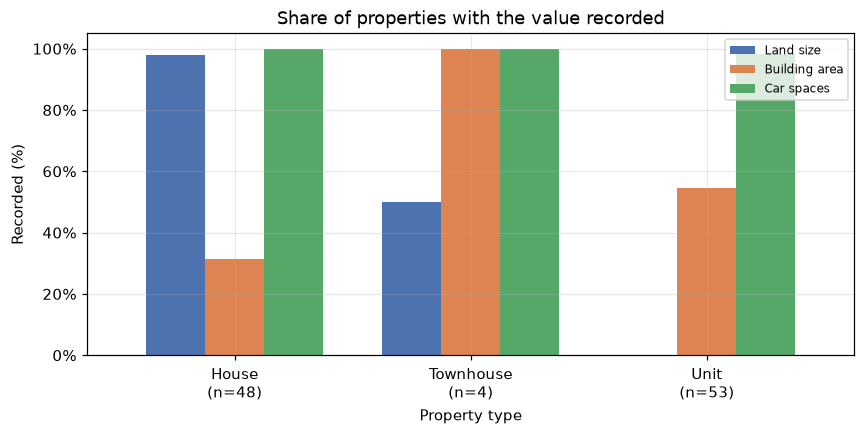

In [4]:
# The CSV mixes original and already-derived columns; check every column is accounted for.
id_columns = ["property_id", "address", "sale_date", "property_latitude", "property_longitude"]
all_known = ORIGINAL_NUMERIC + ORIGINAL_CATEGORICAL + ENGINEERED_IN_CSV + id_columns + [TARGET]
assert set(all_known) == set(raw.columns)

print("Missing values:", raw.isna().sum()[raw.isna().sum() > 0].to_dict())

size_cols = ["land_size_sqm", "building_size_sqm", "car_spaces"]
recorded_pct = raw.groupby("property_type")[size_cols].count().div(raw["property_type"].value_counts(), axis=0) * 100
recorded_pct = recorded_pct.loc[TYPE_ORDER]
type_counts = raw["property_type"].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.8))
recorded_pct.plot(kind="bar", ax=ax, width=0.75, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_xticklabels([f"{t}\n(n={type_counts[t]})" for t in TYPE_ORDER], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Share of properties with the value recorded", xlabel="Property type", ylabel="Recorded (%)", ylim=(0, 105))
ax.legend(["Land size", "Building area", "Car spaces"], fontsize=8)
save(fig, "01_missingness")
plt.show()

Most of the missing data is structural:
- **Land size** is missing for all 53 units. A strata unit does not have its own land parcel, so I handle this separately instead of treating it as unknown. It is also missing for 2 townhouses and one house.
- **Building area** is recorded for only 15 of 48 houses.
- **Car spaces** is missing for one property where the sources disagreed.

I did not fill these in the dataset. Imputation happens inside the model pipeline (Section 5).

### Holdout set

Before looking at the data, I set aside 10 properties (stratified by suburb) as a final holdout. They are only used in Sections 8 and 10. Everything else uses the other 95 properties.

In [5]:
# Keep the 10-property holdout untouched until model selection is finished.
dev, holdout = train_test_split(raw, test_size=10, stratify=raw["suburb"], random_state=SEED)
dev = dev.sort_values("property_id").reset_index(drop=True)
holdout = holdout.sort_values("property_id").reset_index(drop=True)

print("Development set:", len(dev), "| Holdout:", len(holdout))
holdout[["property_id", "suburb", "property_type", "bedrooms", "bathrooms", TARGET]]

Development set: 95 | Holdout: 10


,property_id,suburb,property_type,bedrooms,bathrooms,sale_price
0,SYD-008,Blacktown,Townhouse,3,2,750000
1,SYD-015,Blacktown,House,3,1,900000
2,SYD-029,Blacktown,House,3,1,1600000
3,SYD-045,Parramatta,Unit,2,2,650000
4,SYD-053,Parramatta,Unit,1,1,435000
5,SYD-061,Parramatta,House,3,1,1610000
6,SYD-065,Parramatta,House,3,2,1620000
7,SYD-073,Mosman,Unit,2,2,4500000
8,SYD-077,Mosman,Unit,2,1,1600000
9,SYD-091,Mosman,Townhouse,3,2,2380000


The holdout happens to contain no Mosman houses and 2 of the 4 townhouses in the whole dataset. I did not redraw it, since picking a "nicer" split would bias the test.

## 3. Exploratory Data Analysis

All plots in this section use the 95 development properties.

### 3.1 Sale price distribution

Mean $1.8M, median $1.0M
Skewness 5.00 (log scale 1.25)


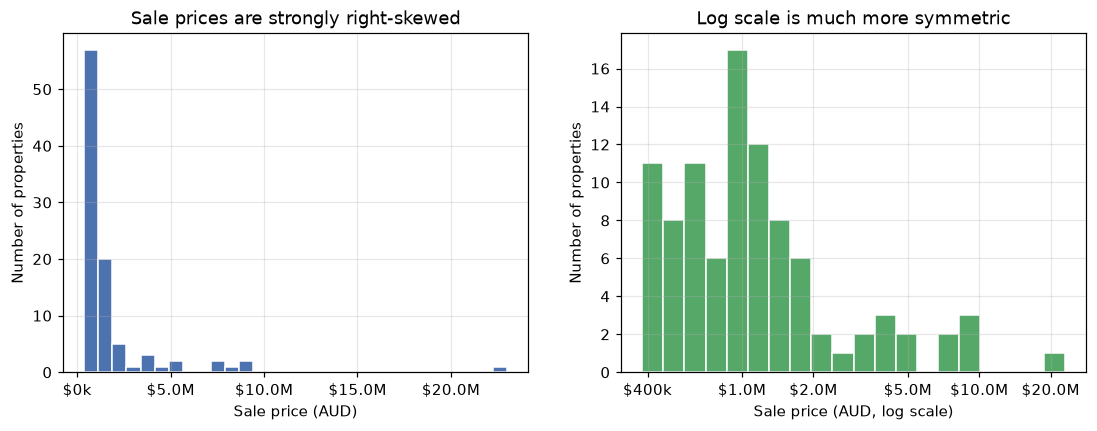

In [6]:
print(f"Mean {aud(dev[TARGET].mean())}, median {aud(dev[TARGET].median())}")
print(f"Skewness {dev[TARGET].skew():.2f} (log scale {np.log(dev[TARGET]).skew():.2f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(dev[TARGET], bins=30, color="#4c72b0", edgecolor="white")
ax[0].xaxis.set_major_formatter(AUD_FMT)
ax[0].set(title="Sale prices are strongly right-skewed", xlabel="Sale price (AUD)", ylabel="Number of properties")

ax[1].hist(np.log10(dev[TARGET]), bins=20, color="#55a868", edgecolor="white")
ticks = [4e5, 1e6, 2e6, 5e6, 1e7, 2e7]
ax[1].set_xticks(np.log10(ticks), [aud(t) for t in ticks])
ax[1].set(title="Log scale is much more symmetric", xlabel="Sale price (AUD, log scale)", ylabel="Number of properties")
save(fig, "02_price_distribution")
plt.show()

The mean ($1.83M) is far above the median ($1.01M) because of a few very expensive Mosman sales. On a log scale the skewness drops from 5.00 to 1.25, so the models predict log(price) and I convert back to dollars for evaluation.

### 3.2 Suburb and property type

property_type,House,Townhouse,Unit,All types
suburb,,,,
Blacktown,"$1,066,250","$920,000","$455,000","$1,003,750"
Parramatta,"$1,771,000","$780,000","$560,000","$640,000"
Mosman,"$5,300,000",–,"$1,025,000","$1,510,000"


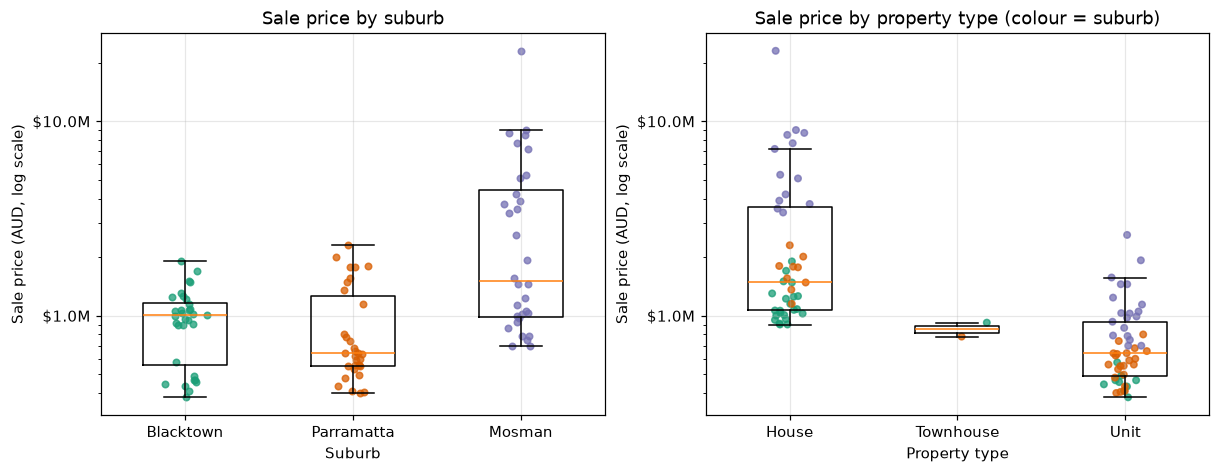

In [7]:
median_table = dev.pivot_table(index="suburb", columns="property_type", values=TARGET, aggfunc="median")
median_table = median_table.loc[SUBURB_ORDER, TYPE_ORDER]
median_table["All types"] = dev.groupby("suburb")[TARGET].median()
display(median_table.style.format("${:,.0f}", na_rep="–"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
rng = np.random.default_rng(SEED)
for i, suburb in enumerate(SUBURB_ORDER, start=1):
    prices = dev.loc[dev["suburb"] == suburb, TARGET]
    ax[0].boxplot(prices, positions=[i], widths=0.5, showfliers=False)
    ax[0].scatter(rng.normal(i, 0.06, len(prices)), prices, s=18, alpha=0.75, color=COLOURS[suburb])
ax[0].set_xticks([1, 2, 3], SUBURB_ORDER)
ax[0].set(title="Sale price by suburb", xlabel="Suburb")

for i, prop_type in enumerate(TYPE_ORDER, start=1):
    rows = dev[dev["property_type"] == prop_type]
    ax[1].boxplot(rows[TARGET], positions=[i], widths=0.5, showfliers=False)
    ax[1].scatter(rng.normal(i, 0.06, len(rows)), rows[TARGET], s=18, alpha=0.75, c=rows["suburb"].map(COLOURS))
ax[1].set_xticks([1, 2, 3], TYPE_ORDER)
ax[1].set(title="Sale price by property type (colour = suburb)", xlabel="Property type")

for a in ax:
    a.set_yscale("log")
    dollar_axis(a.yaxis)
    a.set_ylabel("Sale price (AUD, log scale)")
save(fig, "03_price_by_suburb_type")
plt.show()

Suburb medians are Blacktown $1,003,750, Parramatta $640,000 and Mosman $1,510,000. Suburb and type are mixed together: Blacktown's sample is mostly houses and Parramatta's mostly units. Comparing the same type, Parramatta houses ($1.77M) cost more than Blacktown houses ($1.07M), and Mosman houses have a median of $5.3M.

### 3.3 Size, land and building area

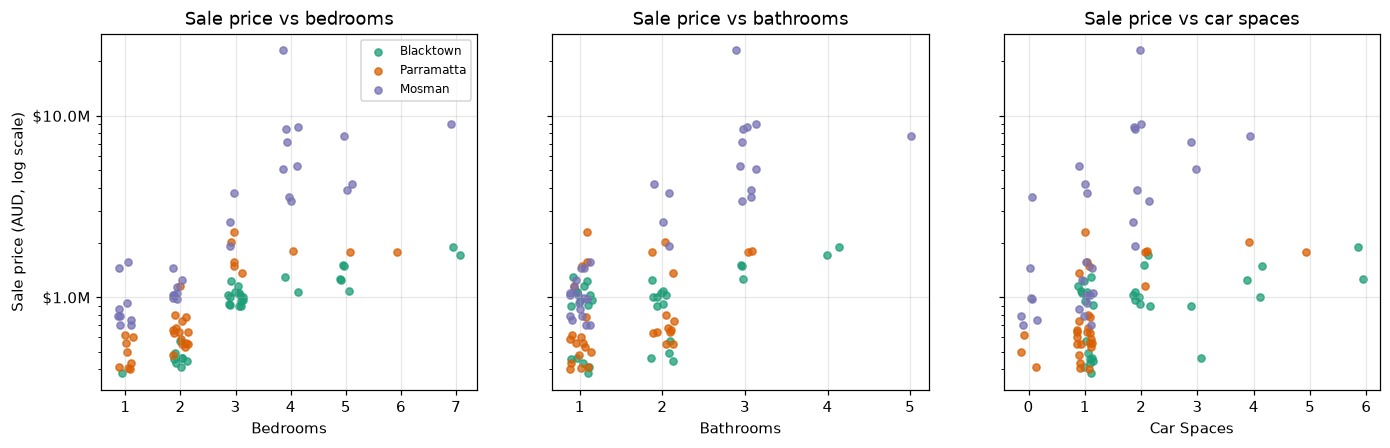

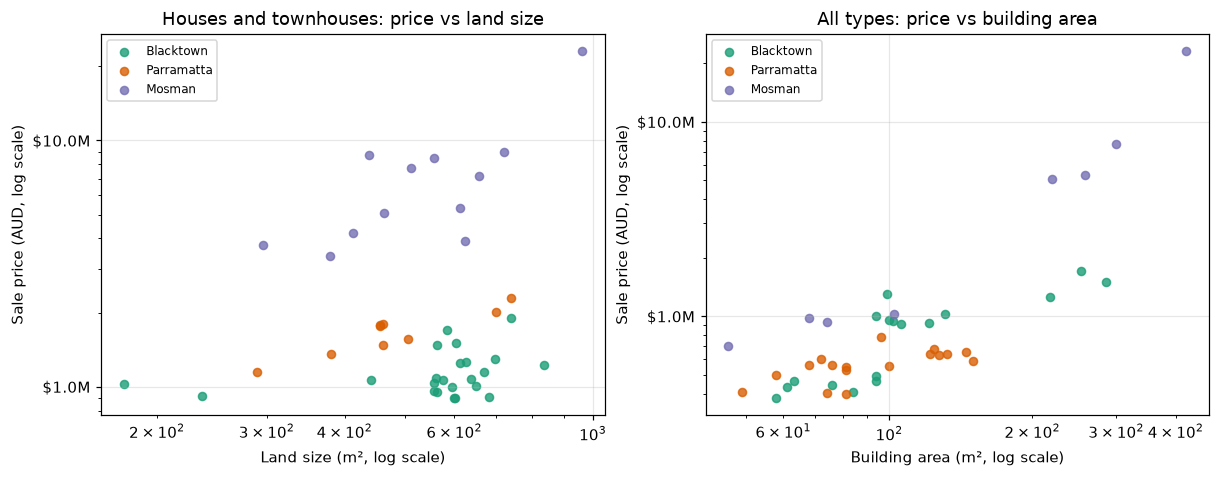

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, col in zip(axes, ["bedrooms", "bathrooms", "car_spaces"]):
    for suburb in SUBURB_ORDER:
        rows = dev[dev["suburb"] == suburb]
        jitter = rng.uniform(-0.15, 0.15, len(rows))
        ax.scatter(rows[col] + jitter, rows[TARGET], s=22, alpha=0.75, color=COLOURS[suburb], label=suburb)
    ax.set(yscale="log", xlabel=col.replace("_", " ").title(), title=f"Sale price vs {col.replace('_', ' ')}")
    dollar_axis(ax.yaxis)
axes[0].set_ylabel("Sale price (AUD, log scale)")
axes[0].legend(fontsize=8)
save(fig, "04_rooms_parking")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
landed = dev[(dev["property_type"] != "Unit") & dev["land_size_sqm"].notna()]
for suburb in SUBURB_ORDER:
    rows = landed[landed["suburb"] == suburb]
    ax[0].scatter(rows["land_size_sqm"], rows[TARGET], s=28, alpha=0.8, color=COLOURS[suburb], label=suburb)
ax[0].set(title="Houses and townhouses: price vs land size", xlabel="Land size (m², log scale)")

with_building = dev[dev["building_size_sqm"].notna()]
for suburb in SUBURB_ORDER:
    rows = with_building[with_building["suburb"] == suburb]
    ax[1].scatter(rows["building_size_sqm"], rows[TARGET], s=28, alpha=0.8, color=COLOURS[suburb], label=suburb)
ax[1].set(title="All types: price vs building area", xlabel="Building area (m², log scale)")

for a in ax:
    a.set(xscale="log", yscale="log", ylabel="Sale price (AUD, log scale)")
    dollar_axis(a.yaxis)
    a.legend(fontsize=8)
save(fig, "05_land_building")
plt.show()

- Price rises with bedrooms, bathrooms and parking **within** each suburb, but not always overall (4-bedroom sales have a higher median than 5-bedroom sales because most of them are Mosman houses).
- Land size has almost no overall relationship with price (Spearman ρ = 0.06) but a clear positive one within suburbs. Blacktown has the biggest blocks and the cheapest houses.
- Building area is strongly related to price (ρ = 0.70), but that is mostly the unit–house difference, and it is missing for most houses.

### 3.4 Time

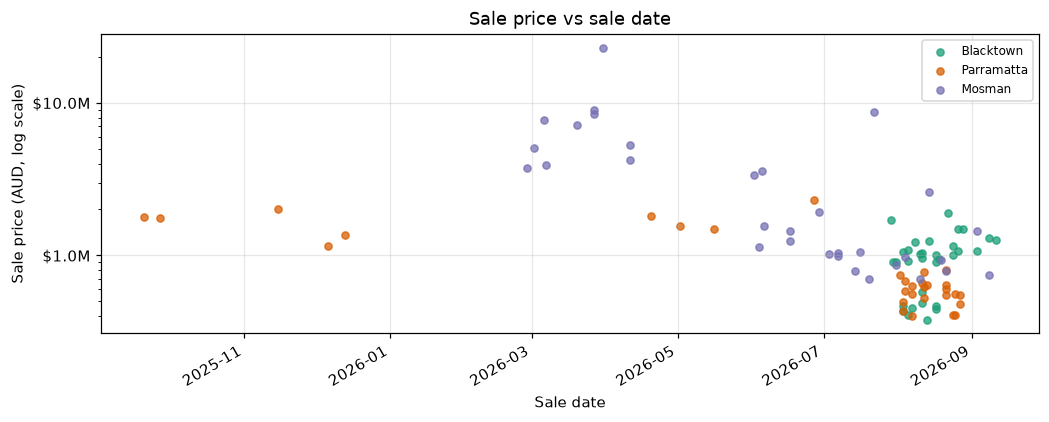

Sales per year: {2025: 5, 2026: 90}


,suburb,type,n,first sale,last sale,"Spearman ρ (date, price)"
0,Blacktown,House,22,2026-07-29,2026-09-11,0.38
1,Blacktown,Unit,9,2026-08-03,2026-08-17,0.08
2,Mosman,House,13,2026-02-27,2026-07-22,0.00
3,Mosman,Unit,19,2026-06-04,2026-09-08,-0.46
4,Parramatta,House,9,2025-09-20,2026-06-27,0.07
5,Parramatta,Unit,21,2026-08-02,2026-08-27,-0.22


In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
for suburb in SUBURB_ORDER:
    rows = dev[dev["suburb"] == suburb]
    ax.scatter(rows["sale_date"], rows[TARGET], s=22, alpha=0.75, color=COLOURS[suburb], label=suburb)
ax.set(yscale="log", title="Sale price vs sale date", xlabel="Sale date", ylabel="Sale price (AUD, log scale)")
dollar_axis(ax.yaxis)
ax.legend(fontsize=8)
fig.autofmt_xdate()
save(fig, "06_time_pattern")
plt.show()

days = (dev["sale_date"] - dev["sale_date"].min()).dt.days
print("Sales per year:", dev["sale_date"].dt.year.value_counts().sort_index().to_dict())

rows = []
for (suburb, prop_type), group in dev.groupby(["suburb", "property_type"]):
    if len(group) >= 8:
        rho = stats.spearmanr(days[group.index], group[TARGET])[0]
        rows.append({"suburb": suburb, "type": prop_type, "n": len(group),
                     "first sale": group["sale_date"].min().date(), "last sale": group["sale_date"].max().date(),
                     "Spearman ρ (date, price)": round(rho, 2)})
pd.DataFrame(rows)

In Mosman, price and date look strongly related at suburb level (ρ = −0.74), but within each suburb × type group the relationship is weak or inconsistent. This happens because different segments were sold in different months (Mosman houses February–July, Mosman units June–September). With about one year of sales, I did not use time as a predictor.

### 3.5 Outliers

Above raw-scale IQR fence ($2.9M): 13 sales, {('Mosman', 'House'): 13}
Above log-scale IQR fence ($5.7M): 6 sales
Price SD with / without SYD-098: $2.9M / $1.9M


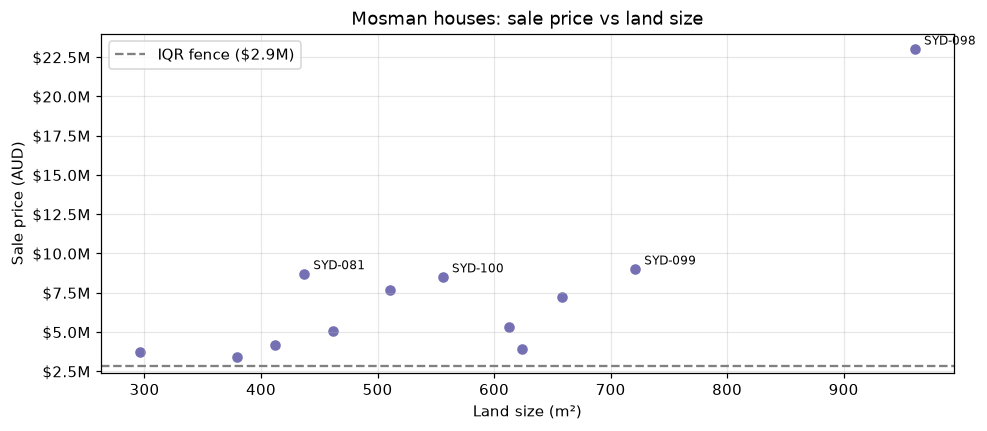

In [10]:
q1, q3 = dev[TARGET].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
log_q1, log_q3 = np.log(dev[TARGET]).quantile([0.25, 0.75])
log_upper_fence = np.exp(log_q3 + 1.5 * (log_q3 - log_q1))

flagged = dev[dev[TARGET] > upper_fence]
print(f"Above raw-scale IQR fence ({aud(upper_fence)}): {len(flagged)} sales,",
      flagged.groupby(["suburb", "property_type"]).size().to_dict())
print(f"Above log-scale IQR fence ({aud(log_upper_fence)}): {(flagged[TARGET] > log_upper_fence).sum()} sales")

without_098 = dev[dev["property_id"] != "SYD-098"]
print(f"Price SD with / without SYD-098: {aud(dev[TARGET].std())} / {aud(without_098[TARGET].std())}")

mosman_houses = dev[(dev["suburb"] == "Mosman") & (dev["property_type"] == "House")]
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(mosman_houses["land_size_sqm"], mosman_houses[TARGET], s=35, color=COLOURS["Mosman"])
for _, row in mosman_houses.nlargest(4, TARGET).iterrows():
    ax.annotate(row["property_id"], (row["land_size_sqm"], row[TARGET]), xytext=(6, 3), textcoords="offset points", fontsize=8)
ax.axhline(upper_fence, ls="--", color="grey", label=f"IQR fence ({aud(upper_fence)})")
ax.set(title="Mosman houses: sale price vs land size", xlabel="Land size (m²)", ylabel="Sale price (AUD)")
ax.yaxis.set_major_formatter(AUD_FMT)
ax.legend()
save(fig, "07_mosman_outliers")
plt.show()

The IQR rule flags 13 sales, all Mosman houses, but only 6 on the log scale, so most are simply the top end of the Mosman market. SYD-098 ($23M) is extreme, but its large land (961 m²) and building area (421 m²) fit a luxury home and nothing suggests an error. **I kept all of these sales.** Removing genuine sales would only make the model look better than it is. Section 7 includes a sensitivity check without SYD-098.

## 4. Important Original Variables

Before any feature engineering, I looked for the three original variables most strongly linked to price. Numeric and categorical variables need different statistics, so I kept them in separate tables:
- **Numeric:** Spearman ρ with price, plus the mean of the suburb-specific Spearman correlations (ρ calculated in each suburb, then averaged). The second number shows whether a relationship holds inside suburbs.
- **Categorical:** Kruskal–Wallis test with ε² as the effect size.

In [11]:
numeric_rows = []
for col in ORIGINAL_NUMERIC:
    known = dev[dev[col].notna()]
    pooled_rho = stats.spearmanr(known[col], known[TARGET])[0]

    suburb_rhos = []
    for suburb in SUBURB_ORDER:
        in_suburb = known[known["suburb"] == suburb]
        if in_suburb[col].nunique() > 1:
            suburb_rhos.append(stats.spearmanr(in_suburb[col], in_suburb[TARGET])[0])

    numeric_rows.append({"variable": col, "n": len(known), "Spearman ρ": pooled_rho,
                         "mean of suburb-specific ρ": np.nanmean(suburb_rhos)})

numeric_table = pd.DataFrame(numeric_rows).set_index("variable")
numeric_table = numeric_table.sort_values("Spearman ρ", key=abs, ascending=False)
display(numeric_table.round(2))

categorical_rows = []
for col in ORIGINAL_CATEGORICAL:
    groups = [group[TARGET] for _, group in dev.groupby(col)]
    h, p = stats.kruskal(*groups)
    epsilon_sq = (h - len(groups) + 1) / (len(dev) - len(groups))
    categorical_rows.append({"variable": col, "Kruskal–Wallis p": f"{p:.1e}", "ε²": round(epsilon_sq, 2)})
display(pd.DataFrame(categorical_rows).set_index("variable"))

# Check that the property-type effect is not just a suburb effect.
house_unit = dev[dev["property_type"] != "Townhouse"].pivot_table(index="suburb", columns="property_type", values=TARGET, aggfunc="median")
house_unit["house / unit ratio"] = house_unit["House"] / house_unit["Unit"]
house_unit.loc[SUBURB_ORDER].round(2)

,n,Spearman ρ,mean of suburb-specific ρ
variable,,,
bedrooms,95,0.75,0.88
building_size_sqm,42,0.70,0.82
distance_to_nearest_train_station_km,95,0.63,0.34
regular_bus_routes_within_1km,95,-0.60,-0.50
regular_bus_routes_within_500m,95,-0.56,-0.38
bathrooms,95,0.53,0.60
car_spaces,94,0.47,0.57
distance_to_sydney_gpo_km,95,-0.29,0.18
regular_bus_routes_within_250m,95,-0.25,-0.23


,Kruskal–Wallis p,ε²
variable,,
suburb,9.9e-06,0.23
property_type,3.7e-11,0.50


property_type,House,Unit,house / unit ratio
suburb,,,
Blacktown,1066250.0,455000.0,2.34
Parramatta,1771000.0,560000.0,3.16
Mosman,5300000.0,1025000.0,5.17


**My three most important variables:**
1. **Property type:** the largest effect (ε² = 0.50). Within every suburb houses sell for 2.3–5.2 times the unit median.
2. **Suburb:** ε² = 0.23. This number understates it because suburb is mixed up with property type; for the same type the gaps are large.
3. **Bedrooms:** the strongest numeric variable (Spearman ρ = 0.75), and even stronger within suburbs (mean of the suburb-specific Spearman correlations = 0.88). It is recorded for every property.

Building area (ρ = 0.70) is only recorded for 42 of 95 properties, and distance to a train station (ρ = 0.63) mostly reflects that Mosman has no railway (mean suburb-specific ρ = 0.34), so I did not pick them. These are associations, not causes.

## 5. Feature Engineering

First I checked the accessibility variables, because several of them looked like they might just be measuring suburb.

Share of GPO-distance variance explained by suburb: 0.994


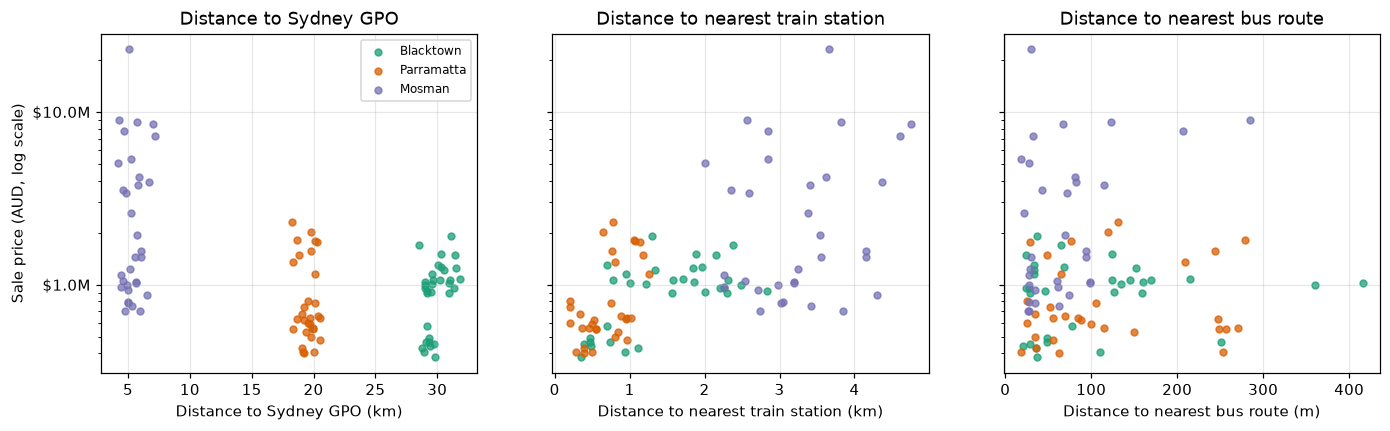

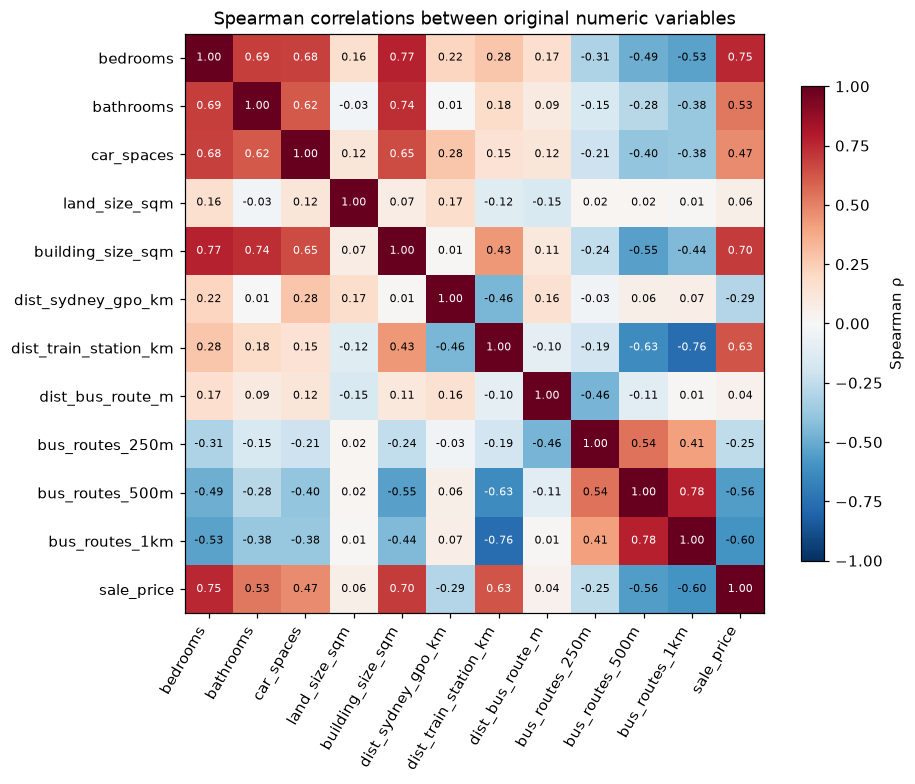

In [12]:
suburb_mean = dev.groupby("suburb")["distance_to_sydney_gpo_km"].transform("mean")
overall_mean = dev["distance_to_sydney_gpo_km"].mean()
between = ((suburb_mean - overall_mean) ** 2).sum()
total = ((dev["distance_to_sydney_gpo_km"] - overall_mean) ** 2).sum()
print(f"Share of GPO-distance variance explained by suburb: {between / total:.3f}")

access_cols = ["distance_to_sydney_gpo_km", "distance_to_nearest_train_station_km", "distance_to_nearest_bus_route_m"]
access_labels = ["Distance to Sydney GPO (km)", "Distance to nearest train station (km)", "Distance to nearest bus route (m)"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col, label in zip(axes, access_cols, access_labels):
    for suburb in SUBURB_ORDER:
        rows = dev[dev["suburb"] == suburb]
        ax.scatter(rows[col], rows[TARGET], s=20, alpha=0.75, color=COLOURS[suburb], label=suburb)
    ax.set(yscale="log", xlabel=label, title=label.split(" (")[0])
    dollar_axis(ax.yaxis)
axes[0].set_ylabel("Sale price (AUD, log scale)")
axes[0].legend(fontsize=8)
save(fig, "08_accessibility")
plt.show()

corr = dev[ORIGINAL_NUMERIC + [TARGET]].corr(method="spearman")
short_names = [c.replace("distance_to_", "dist_").replace("regular_bus_routes_within_", "bus_routes_").replace("nearest_", "")
               for c in corr.columns]
fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(short_names)), short_names, rotation=60, ha="right")
ax.set_yticks(range(len(short_names)), short_names)
for i in range(len(short_names)):
    for j in range(len(short_names)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(value) > 0.6 else "black")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Spearman correlations between original numeric variables")
save(fig, "09_spearman_heatmap")
plt.show()

- Suburb explains 99.4% of the variance in distance to the GPO, so this variable adds nothing once suburb is in the model. I dropped it.
- Train-station distance looks positively related to price only because Mosman has no railway.
- The three bus-route counts measure the same thing, so I kept only the 500 m count.

**Feature decisions:**

| Decision | Reason |
|---|---|
| One-hot encode suburb and property type | Strongest group effects |
| `private_land_sqm` = 0 for units, recorded land otherwise | Units have no private land parcel |
| Fill remaining missing land, building area and car spaces with the training median for that property type, and add a flag | Filled values are placeholders, and the flags let the model know |
| Add `bathrooms_per_bedroom` | Captures amenity beyond raw room counts |
| log(1 + x) for land, building area and distances | Skewed variables |
| Drop GPO distance, two bus counts, time, IDs and coordinates | Suburb proxies, collection artefacts or memorisation risk |
| Predict log(price) | Reduces the pull of luxury sales, though expensive homes will tend to be under-predicted |

All of this is done inside a scikit-learn pipeline, so in cross-validation the medians, scaling and encoding are learned from the training folds only.

In [13]:
LOG_COLS = ["private_land_sqm", "building_size_sqm", "distance_to_nearest_train_station_km", "distance_to_nearest_bus_route_m"]
OTHER_NUMERIC = [c for c in ENGINEERED_NUMERIC if c not in LOG_COLS]
IMPUTE_COLS = ["private_land_sqm", "building_size_sqm", "car_spaces"]


def make_pipeline_steps(scale):
    # Ridge needs scaled inputs; the tree models do not.
    if scale:
        log_step = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("scale", StandardScaler())])
        other_step = StandardScaler()
    else:
        log_step = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
        other_step = "passthrough"

    encoder = ColumnTransformer([
        ("log", log_step, LOG_COLS),
        ("num", other_step, OTHER_NUMERIC),
        ("flag", "passthrough", FLAGS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), MODEL_CATEGORICAL),
    ], verbose_feature_names_out=False)

    return [("features", HousingFeatures()), ("impute", GroupMedianImputer(IMPUTE_COLS)), ("encode", encoder)]


def make_model(regressor, scale):
    # Fit on log(price) and convert predictions back to dollars.
    pipeline = Pipeline(make_pipeline_steps(scale) + [("model", regressor)])
    return TransformedTargetRegressor(regressor=pipeline, func=np.log, inverse_func=np.exp)


X_dev = dev[MODEL_INPUTS]
y_dev = dev[TARGET]

preview = Pipeline(make_pipeline_steps(scale=False)).fit(X_dev)
feature_names = preview.named_steps["encode"].get_feature_names_out()
print(len(feature_names), "features:", list(feature_names))

18 features: ['private_land_sqm', 'building_size_sqm', 'distance_to_nearest_train_station_km', 'distance_to_nearest_bus_route_m', 'bedrooms', 'bathrooms', 'car_spaces', 'regular_bus_routes_within_500m', 'bathrooms_per_bedroom', 'land_unknown', 'building_unknown', 'car_unknown', 'suburb_Blacktown', 'suburb_Mosman', 'suburb_Parramatta', 'property_type_House', 'property_type_Townhouse', 'property_type_Unit']


## 6. Model Development

| Model | Why I chose it | Expected weakness |
|---|---|---|
| Baseline: suburb × property-type median | The minimum a real model should beat | Ignores size and land |
| Ridge Regression | Simple, stable linear model | Cannot learn interactions such as "land matters more in Mosman" |
| Random Forest Regressor | Handles non-linear effects and interactions | Cannot predict above the highest training price |
| Gradient Boosting Regressor | Often strong on tabular data | Most likely to overfit 95 rows |

**My expectation before training:** a tree model (Random Forest or Gradient Boosting) would have the lowest error, because prices depend on suburb × type interactions. I also expected every model to struggle with Mosman luxury houses.

The settings are fixed and conservative. With only about 19 properties in each validation fold, tuning with a grid search would mostly fit noise.

**Evaluation:** 5-fold cross-validation on the 95 development properties, using MAE (average dollar error), RMSE (dominated by big misses), R² and MdAPE (median absolute percentage error).

In [14]:
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "Baseline (suburb × type median)": GroupMedianRegressor(),
    "Ridge Regression": make_model(RidgeCV(alphas=np.logspace(-2, 3, 21)), scale=True),
    "Random Forest Regressor": make_model(RandomForestRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.5,
                                                                random_state=SEED, n_jobs=-1), scale=False),
    "Gradient Boosting Regressor": make_model(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=2,
                                                                        subsample=0.8, min_samples_leaf=3, random_state=SEED), scale=False),
}


def metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return {"MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted),
            "MdAPE": np.median(np.abs(predicted - actual) / actual) * 100}


def cross_validate_model(model, X, y, cv):
    # Returns one row per fold with validation and training metrics.
    rows = []
    for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
        fitted = sklearn.base.clone(model).fit(X.iloc[train_idx], y.iloc[train_idx])
        val = metrics(y.iloc[val_idx], fitted.predict(X.iloc[val_idx]))
        train = metrics(y.iloc[train_idx], fitted.predict(X.iloc[train_idx]))
        row = {"fold": fold}
        for name in val:
            row["val_" + name] = val[name]
            row["train_" + name] = train[name]
        rows.append(row)
    return pd.DataFrame(rows).set_index("fold")


def summarise(fold_results):
    rows = []
    for name, folds in fold_results.items():
        rows.append({"Model": name,
                     "CV MAE": folds["val_MAE"].mean(), "CV MAE SD": folds["val_MAE"].std(),
                     "CV RMSE": folds["val_RMSE"].mean(), "CV R²": folds["val_R2"].mean(),
                     "CV MdAPE %": folds["val_MdAPE"].mean(),
                     "Train MAE": folds["train_MAE"].mean(), "Train R²": folds["train_R2"].mean()})
    return pd.DataFrame(rows).set_index("Model")


cv_results = {}
for name, model in models.items():
    cv_results[name] = cross_validate_model(model, X_dev, y_dev, CV)

## 7. Cross-Validation and Model Comparison

In [15]:
comparison = summarise(cv_results)
comparison.style.format({"CV MAE": "${:,.0f}", "CV MAE SD": "${:,.0f}", "CV RMSE": "${:,.0f}", "Train MAE": "${:,.0f}",
                         "CV R²": "{:.3f}", "Train R²": "{:.3f}", "CV MdAPE %": "{:.1f}"})

,CV MAE,CV MAE SD,CV RMSE,CV R²,CV MdAPE %,Train MAE,Train R²
Model,,,,,,,
Baseline (suburb × type median),"$603,158","$540,154","$1,419,322",0.555,14.6,"$578,911",0.568
Ridge Regression,"$590,461","$484,766","$1,476,827",0.579,15.5,"$491,077",0.679
Random Forest Regressor,"$608,836","$557,279","$1,424,427",0.636,16.0,"$351,960",0.750
Gradient Boosting Regressor,"$605,463","$412,681","$1,462,184",0.513,16.7,"$95,737",0.992


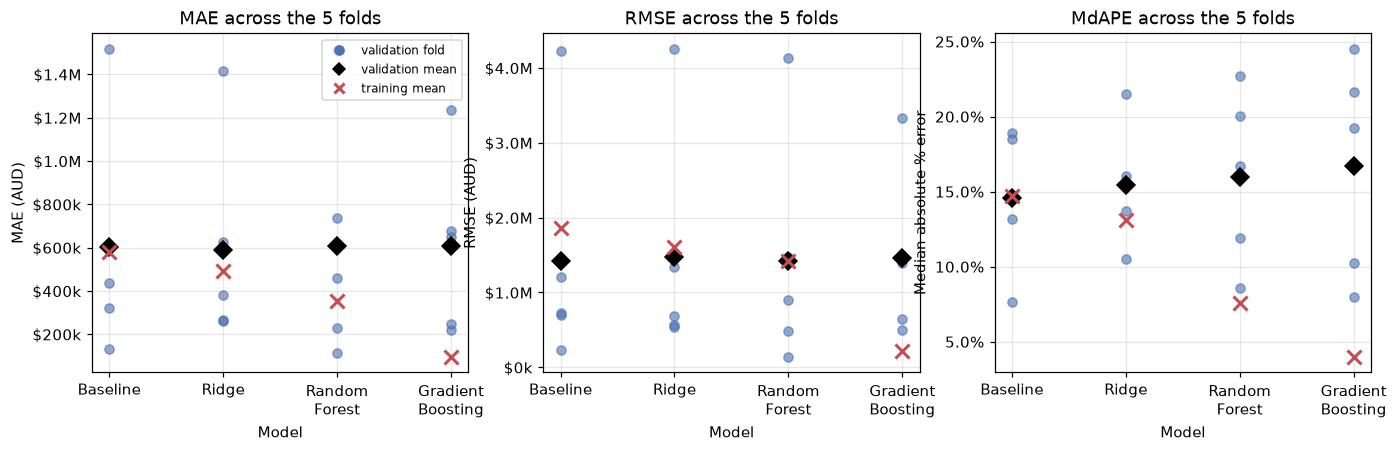

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
short_labels = ["Baseline", "Ridge", "Random\nForest", "Gradient\nBoosting"]
for ax, metric in zip(axes, ["MAE", "RMSE", "MdAPE"]):
    for i, name in enumerate(cv_results):
        folds = cv_results[name]
        ax.plot([i] * 5, folds["val_" + metric], "o", alpha=0.6, color="#4c72b0")
        ax.plot(i, folds["val_" + metric].mean(), "D", color="black", ms=8)
        ax.plot(i, folds["train_" + metric].mean(), "x", color="#c44e52", ms=9, mew=2)
    ax.set_xticks(range(4), short_labels)
    ax.set(title=f"{metric} across the 5 folds", xlabel="Model")
    if metric == "MdAPE":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel("Median absolute % error")
    else:
        ax.yaxis.set_major_formatter(AUD_FMT)
        ax.set_ylabel(metric + " (AUD)")
axes[0].legend(handles=[plt.Line2D([], [], marker="o", ls="", color="#4c72b0", label="validation fold"),
                        plt.Line2D([], [], marker="D", ls="", color="black", label="validation mean"),
                        plt.Line2D([], [], marker="x", ls="", color="#c44e52", mew=2, label="training mean")], fontsize=8)
save(fig, "10_cv_folds")
plt.show()

- **Different metrics favour different models.** Ridge has the lowest MAE ($590,461), the baseline has the lowest RMSE ($1,419,322) and MdAPE (14.6%), and Random Forest has the highest R² (0.636).
- **The differences are small.** All four MAEs are within about $18k, while MAE varies by $410k–$560k between folds. One fold holds three sales above $7M and has an MAE over $1.2M for every model.
- **Overfitting:** Gradient Boosting has a **training R² of 0.992 but a CV R² of 0.513** (training MAE $95,737), so it nearly memorises the training folds. Ridge and the baseline have small train–validation gaps and high error, which suggests underfitting.

### 7.1 Model complexity

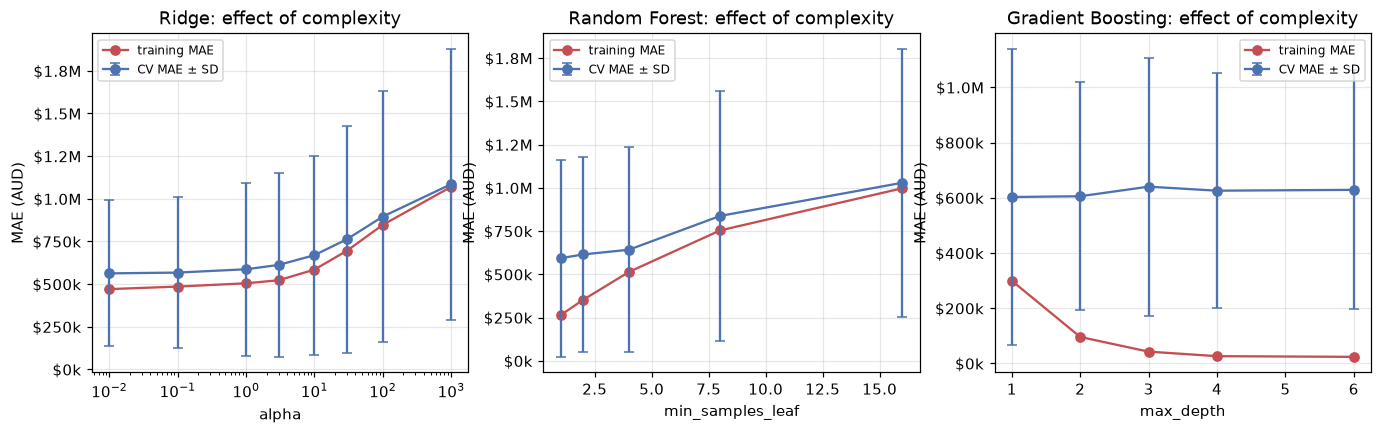

In [17]:
def complexity_curve(build_model, values):
    rows = []
    for value in values:
        folds = cross_validate_model(build_model(value), X_dev, y_dev, CV)
        rows.append({"value": value, "train_MAE": folds["train_MAE"].mean(),
                     "val_MAE": folds["val_MAE"].mean(), "val_MAE_sd": folds["val_MAE"].std()})
    return pd.DataFrame(rows)


def ridge_with_alpha(alpha):
    return make_model(Ridge(alpha=alpha), scale=True)


def forest_with_leaf(leaf):
    return make_model(RandomForestRegressor(300, min_samples_leaf=leaf, max_features=0.5, random_state=SEED, n_jobs=-1), scale=False)


def boosting_with_depth(depth):
    return make_model(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=depth, subsample=0.8,
                                                min_samples_leaf=3, random_state=SEED), scale=False)


curves = [
    ("Ridge", "alpha", complexity_curve(ridge_with_alpha, [0.01, 0.1, 1, 3, 10, 30, 100, 1000])),
    ("Random Forest", "min_samples_leaf", complexity_curve(forest_with_leaf, [1, 2, 4, 8, 16])),
    ("Gradient Boosting", "max_depth", complexity_curve(boosting_with_depth, [1, 2, 3, 4, 6])),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, param, curve) in zip(axes, curves):
    ax.plot(curve["value"], curve["train_MAE"], "o-", color="#c44e52", label="training MAE")
    ax.errorbar(curve["value"], curve["val_MAE"], yerr=curve["val_MAE_sd"], fmt="o-", color="#4c72b0", capsize=3, label="CV MAE ± SD")
    if param == "alpha":
        ax.set_xscale("log")
    ax.set(title=f"{model_name}: effect of complexity", xlabel=param, ylabel="MAE (AUD)")
    ax.yaxis.set_major_formatter(AUD_FMT)
    ax.legend(fontsize=8)
save(fig, "11_complexity")
plt.show()

I used these curves only to understand the models; I did not change the settings afterwards.
- **Ridge:** error keeps falling as α gets smaller, and training and validation error move together, so it is limited by being linear (underfitting).
- **Random Forest:** big leaves underfit; smaller leaves widen the train–validation gap without much change in validation error.
- **Gradient Boosting:** deeper trees push training MAE down to $24k–$43k while validation MAE gets worse ($626k–$640k). This is the clearest sign of overfitting.

### 7.2 Repeated splits and a sensitivity check

One 5-fold split was not decisive, so I repeated the cross-validation with five more random shuffles (six splits in total, still only the development set). I also re-ran it without SYD-098 to see how much one $23M sale affects the metrics. SYD-098 stays in the data.

In [18]:
SPLIT_SEEDS = [SEED, 0, 1, 2, 3, 4]

split_summaries = {}
for seed in SPLIT_SEEDS:
    if seed == SEED:
        split_summaries[seed] = comparison
        continue
    cv_seed = KFold(n_splits=5, shuffle=True, random_state=seed)
    results = {}
    for name, model in models.items():
        results[name] = cross_validate_model(model, X_dev, y_dev, cv_seed)
    split_summaries[seed] = summarise(results)

mae_by_split = pd.DataFrame({seed: summary["CV MAE"] for seed, summary in split_summaries.items()})
rmse_by_split = pd.DataFrame({seed: summary["CV RMSE"] for seed, summary in split_summaries.items()})
r2_by_split = pd.DataFrame({seed: summary["CV R²"] for seed, summary in split_summaries.items()})
mdape_by_split = pd.DataFrame({seed: summary["CV MdAPE %"] for seed, summary in split_summaries.items()})

lowest_mae_model = mae_by_split.idxmin()  # for each split, the model with the lowest MAE
wins = lowest_mae_model.value_counts().reindex(comparison.index, fill_value=0)

repeated = pd.DataFrame({
    "mean CV MAE (6 splits)": mae_by_split.mean(axis=1),
    "SD across splits": mae_by_split.std(axis=1),
    "mean CV RMSE": rmse_by_split.mean(axis=1),
    "mean CV R²": r2_by_split.mean(axis=1),
    "mean CV MdAPE %": mdape_by_split.mean(axis=1),
    "lowest MAE in # splits": wins,
})
display(repeated.style.format({"mean CV MAE (6 splits)": "${:,.0f}", "SD across splits": "${:,.0f}", "mean CV RMSE": "${:,.0f}",
                               "mean CV R²": "{:.3f}", "mean CV MdAPE %": "{:.1f}"}))

# Sensitivity check only: the main results above keep SYD-098.
keep = dev["property_id"] != "SYD-098"
results_without = {}
for name, model in models.items():
    results_without[name] = cross_validate_model(model, X_dev[keep], y_dev[keep], CV)
without_098 = summarise(results_without)

sensitivity = pd.DataFrame({
    "CV MAE (all 95)": comparison["CV MAE"], "CV MAE (without SYD-098)": without_098["CV MAE"],
    "CV RMSE (all 95)": comparison["CV RMSE"], "CV RMSE (without SYD-098)": without_098["CV RMSE"],
    "CV MdAPE % (all 95)": comparison["CV MdAPE %"], "CV MdAPE % (without SYD-098)": without_098["CV MdAPE %"],
})
sensitivity.round(1)

,mean CV MAE (6 splits),SD across splits,mean CV RMSE,mean CV R²,mean CV MdAPE %,lowest MAE in # splits
Model,,,,,,
Baseline (suburb × type median),"$675,607","$54,398","$1,644,727",0.468,16.2,0
Ridge Regression,"$628,148","$53,046","$1,565,041",0.599,17.0,1
Random Forest Regressor,"$590,194","$16,059","$1,446,811",0.668,16.9,1
Gradient Boosting Regressor,"$561,711","$30,389","$1,340,009",0.652,16.2,4


,CV MAE (all 95),CV MAE (without SYD-098),CV RMSE (all 95),CV RMSE (without SYD-098),CV MdAPE % (all 95),CV MdAPE % (without SYD-098)
Model,,,,,,
Baseline (suburb × type median),603157.9,483486.8,1419322.3,899012.9,14.6,17.0
Ridge Regression,590460.6,426874.3,1476827.1,822766.4,15.5,16.8
Random Forest Regressor,608836.1,436633.2,1424427.4,871255.8,16.0,17.6
Gradient Boosting Regressor,605462.6,397661.5,1462184.0,828593.5,16.7,15.1


- Over six splits, Gradient Boosting has the lowest mean MAE ($561,711 vs $590,194 for Random Forest and $628,148 for Ridge), the lowest mean RMSE, and the lowest MAE in 4 of 6 splits.
- Random Forest has the highest mean R² and is the most stable between splits.
- No model beats the baseline on median percentage error (Gradient Boosting ties at 16.2%). The gains are mainly in dollar errors on expensive homes.
- Without SYD-098, MAE drops by $120k–$210k and RMSE by about 40% for every model, while MdAPE moves by at most about 2.5 percentage points.

### 7.3 Model selection

I decided in advance to pick the regression model with the lowest mean MAE over the six splits. **Gradient Boosting was selected for the final prototype using the repeated-cross-validation mean-MAE criterion. However, model rankings varied across metrics, and the model showed substantial overfitting risk.** On the primary 5-fold split Ridge had the lowest MAE, the baseline the lowest RMSE and MdAPE, and Random Forest the highest R². Gradient Boosting's training R² (0.992) is far above its CV R² (0.513), and its margin over Random Forest (about $28k) is small next to the fold-to-fold variation. Random Forest would be a reasonable, more stable alternative.

My expectation that a tree model would do best was only weakly supported. The bigger limit on accuracy is missing information, not the choice of algorithm.

In [19]:
regression_models = repeated.drop(index="Baseline (suburb × type median)")
selected_name = regression_models["mean CV MAE (6 splits)"].idxmin()
assert selected_name == "Gradient Boosting Regressor"
selected_model = models[selected_name]
print("Selected:", selected_name)

Selected: Gradient Boosting Regressor


### 7.4 Permutation importance

For each validation fold, I shuffle one input at a time and measure how much the MAE increases. This shows what the model relies on, not what causes price.

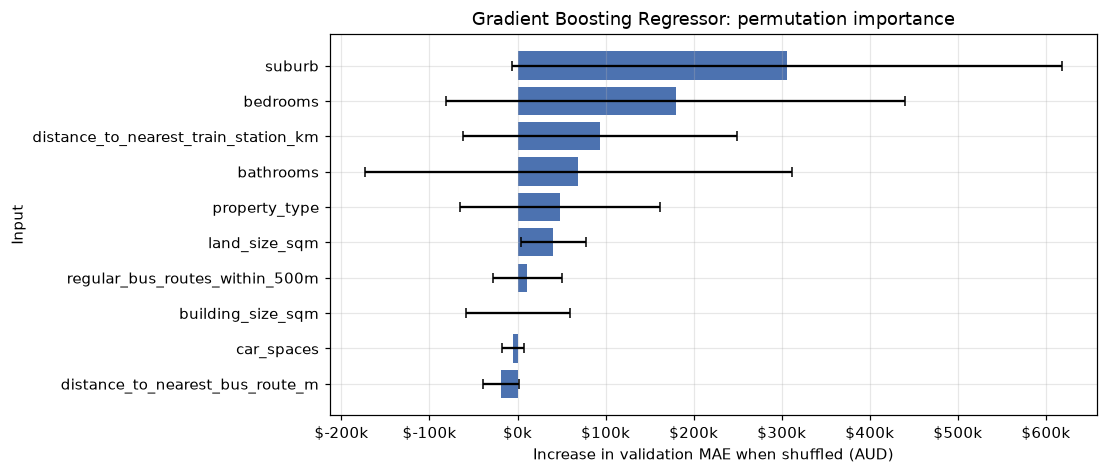

In [20]:
fold_importances = []
for train_idx, val_idx in CV.split(X_dev):
    fitted = sklearn.base.clone(selected_model).fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    result = permutation_importance(fitted, X_dev.iloc[val_idx], y_dev.iloc[val_idx],
                                    scoring="neg_mean_absolute_error", n_repeats=30, random_state=SEED)
    fold_importances.append(pd.Series(result.importances_mean, index=MODEL_INPUTS))

importance = pd.concat(fold_importances, axis=1)
importance_mean = importance.mean(axis=1).sort_values()
importance_sd = importance.std(axis=1)[importance_mean.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(importance_mean.index, importance_mean, xerr=importance_sd, color="#4c72b0", capsize=3)
ax.xaxis.set_major_formatter(AUD_FMT)
ax.set(title="Gradient Boosting Regressor: permutation importance", xlabel="Increase in validation MAE when shuffled (AUD)", ylabel="Input")
save(fig, "12_permutation_importance")
plt.show()

Suburb matters most (+$306k MAE when shuffled), followed by bedrooms (+$180k), which matches Section 4. Property type looks weaker here because its information is shared with land (units = 0) and bedrooms. The error bars are large, so only suburb's top position is clear.

## 8. Final Holdout Evaluation

The selected model is trained on the 95 development properties and then used **once** on the 10 holdout properties.

In [21]:
holdout_model = sklearn.base.clone(selected_model).fit(X_dev, y_dev)
holdout = holdout.copy()
holdout["ml_prediction"] = holdout_model.predict(holdout[MODEL_INPUTS]).round(-3)

holdout_metrics = metrics(holdout[TARGET], holdout["ml_prediction"])
print(f"Holdout: MAE ${holdout_metrics['MAE']:,.0f} | RMSE ${holdout_metrics['RMSE']:,.0f} | "
      f"R² {holdout_metrics['R2']:.3f} | MdAPE {holdout_metrics['MdAPE']:.1f}%")
print(f"CV MAE for comparison: ${comparison.loc[selected_name, 'CV MAE']:,.0f} (one split), "
      f"${repeated.loc[selected_name, 'mean CV MAE (6 splits)']:,.0f} (six splits)")

Holdout: MAE $528,200 | RMSE $1,098,488 | R² 0.034 | MdAPE 12.3%
CV MAE for comparison: $605,463 (one split), $561,711 (six splits)


The holdout is very small, so these results are only a rough check. It has **no Mosman houses** (the hardest segment) and **2 of the 4 townhouses** in the dataset, so the model learned townhouse prices from just 2 examples. One $4.5M Mosman unit (SYD-073) causes most of the holdout error (Section 10).

## 9. Error Analysis

To find the largest errors fairly, I use out-of-fold predictions: each property is predicted by a model that did not see it during training.

In [22]:
# Out-of-fold predictions: each property is predicted by a model that never saw it.
oof_pred = cross_val_predict(selected_model, X_dev, y_dev, cv=CV)
errors = dev.copy()
errors["predicted"] = oof_pred
errors["error"] = errors["predicted"] - errors[TARGET]
errors["abs_error"] = errors["error"].abs()
errors["pct_error"] = errors["error"] / errors[TARGET] * 100

top5 = errors.nlargest(5, "abs_error")
top5_table = top5[["property_id", "suburb", "property_type", TARGET, "predicted", "abs_error", "pct_error"]]
top5_table = top5_table.rename(columns={TARGET: "actual price", "predicted": "OOF prediction", "abs_error": "absolute error", "pct_error": "% error"})
display(top5_table.style.format({"actual price": "${:,.0f}", "OOF prediction": "${:,.0f}", "absolute error": "${:,.0f}", "% error": "{:+.1f}%"}).hide(axis="index"))

print(f"Share of total absolute error: {top5['abs_error'].sum() / errors['abs_error'].sum():.1%}")
print("No detail-page match:", sorted(set(top5["property_id"]) & unmatched_ids))
print("Missing building area:", top5.loc[top5["building_size_sqm"].isna(), "property_id"].tolist())

property_id,suburb,property_type,actual price,OOF prediction,absolute error,% error
SYD-098,Mosman,House,"$23,000,000","$9,109,388","$13,890,612",-60.4%
SYD-099,Mosman,House,"$9,000,000","$3,497,018","$5,502,982",-61.1%
SYD-102,Mosman,House,"$3,900,000","$8,951,400","$5,051,400",+129.5%
SYD-081,Mosman,House,"$8,700,000","$5,701,029","$2,998,971",-34.5%
SYD-101,Mosman,House,"$7,198,000","$10,196,236","$2,998,236",+41.7%


Share of total absolute error: 52.9%
No detail-page match: ['SYD-098', 'SYD-099', 'SYD-101', 'SYD-102']
Missing building area: ['SYD-099', 'SYD-102', 'SYD-081', 'SYD-101']


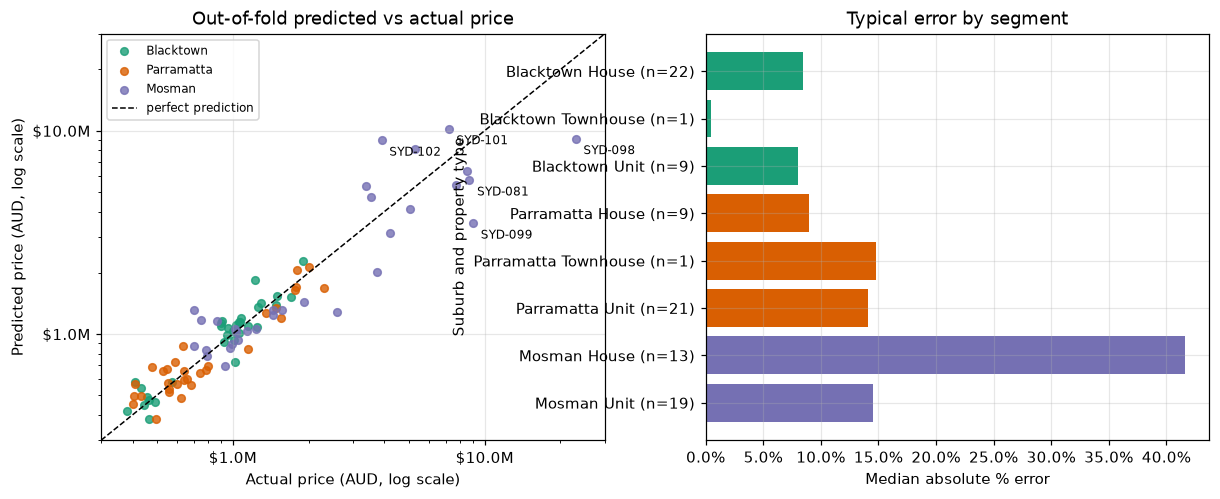

Sales above $5M that were under-predicted: 75% (n = 8)


n  MdAPE
suburb     property_type           
Blacktown  House          22    8.4
           Townhouse       1    0.5
           Unit            9    8.0
Parramatta House           9    9.0
           Townhouse       1   14.8
           Unit           21   14.1
Mosman     House          13   41.7
           Unit           19   14.6

In [23]:
segment_error = errors.groupby(["suburb", "property_type"]).agg(n=("pct_error", "size"),
                                                                MdAPE=("pct_error", lambda s: s.abs().median()))
segment_order = [(s, t) for s in SUBURB_ORDER for t in TYPE_ORDER if (s, t) in segment_error.index]
segment_error = segment_error.loc[segment_order]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for suburb in SUBURB_ORDER:
    rows = errors[errors["suburb"] == suburb]
    ax[0].scatter(rows[TARGET], rows["predicted"], s=25, alpha=0.8, color=COLOURS[suburb], label=suburb)
ax[0].plot([3e5, 3e7], [3e5, 3e7], "k--", lw=1, label="perfect prediction")
for _, row in top5.iterrows():
    ax[0].annotate(row["property_id"], (row[TARGET], row["predicted"]), xytext=(5, -10), textcoords="offset points", fontsize=8)
ax[0].set(xscale="log", yscale="log", xlim=(3e5, 3e7), ylim=(3e5, 3e7), title="Out-of-fold predicted vs actual price",
          xlabel="Actual price (AUD, log scale)", ylabel="Predicted price (AUD, log scale)")
dollar_axis(ax[0].xaxis)
dollar_axis(ax[0].yaxis)
ax[0].legend(fontsize=8)

labels = [f"{s} {t} (n={n})" for (s, t), n in zip(segment_error.index, segment_error["n"])]
colours = [COLOURS[s] for s, _ in segment_error.index]
ax[1].barh(labels[::-1], segment_error["MdAPE"][::-1], color=colours[::-1])
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter())
ax[1].set(title="Typical error by segment", xlabel="Median absolute % error", ylabel="Suburb and property type")
save(fig, "13_oof_errors")
plt.show()

above_5m = errors[errors[TARGET] > 5e6]
print(f"Sales above $5M that were under-predicted: {(above_5m['error'] < 0).mean():.0%} (n = {len(above_5m)})")
segment_error.round(1)

**All five largest errors are Mosman houses**, and together they make up 52.9% of all absolute error.

| Property | Actual | Predicted | Error | Notes |
|---|---|---|---|---|
| SYD-098 | $23.0M | $9.1M | −60% | Largest land and house in Mosman; tree models cannot predict above the highest training price |
| SYD-099 | $9.0M | $3.5M | −61% | 7 bedrooms, but building area is missing and the only other 7-bedroom sales are in Blacktown |
| SYD-102 | $3.9M | $9.0M | +130% | Looks almost the same as SYD-099 in the data, yet sold for $5.1M less |
| SYD-081 | $8.7M | $5.7M | −34% | Smaller-than-usual land but near the top of the price range |
| SYD-101 | $7.2M | $10.2M | +42% | Nothing in the data explains the lower price |

**Why Mosman houses are hard:** the variables I have cannot separate a $4M house from a $9M one. Views, water frontage, street, renovation and architecture are not recorded. There are only about 10 Mosman houses in each training fold, 4 of these 5 have no building area, and 4 have no detail-page price match. Mosman houses have a median error of 41.7%, compared with 0.5–14.8% for every other segment, and 75% of sales above $5M are under-predicted.

Predictions should be used with caution for prestige properties, rare types (townhouses), missing size information and anything outside the range of the training data.

## 10. Gradient Boosting vs ChatGPT vs Human

The 10 holdout properties were estimated in three ways:
- **Gradient Boosting:** predictions from Section 8.
- **ChatGPT (LLM-based estimator):** a large language model given the property details in a prompt. It was not trained on this dataset.
- **Human:** my own estimates.

ChatGPT and the human estimates used only suburb, type, bedrooms, bathrooms, car spaces, land size and building area. Neither saw the address, sale price or Gradient Boosting prediction.

The estimates are stored in `report/llm_human_comparison.csv`. The next cell only refreshes the Gradient Boosting column; the other estimates are never overwritten.

In [24]:
COMPARISON_PATH = ROOT / "report" / "llm_human_comparison.csv"
saved = pd.read_csv(COMPARISON_PATH)
assert set(saved["property_id"]) == set(holdout["property_id"])

info_cols = ["property_id", "suburb", "address", "sale_date", "property_type", "bedrooms", "bathrooms", "car_spaces",
             "land_size_sqm", "building_size_sqm", "distance_to_nearest_train_station_km", "distance_to_nearest_bus_route_m"]
comp = holdout[info_cols].copy()
comp["sale_date"] = comp["sale_date"].dt.strftime("%Y-%m")
comp["actual_price"] = holdout[TARGET]
comp["ml_prediction"] = holdout["ml_prediction"]
comp = comp.merge(saved[["property_id", "llm_estimate", "human_estimate"]], on="property_id")
comp.to_csv(COMPARISON_PATH, index=False)

**Prompt given to ChatGPT** (same format for each property):

```
You are participating in a blind property-price estimation experiment.
Estimate the likely sale price in AUD for each property using ONLY the information provided.
Do not search the web, identify the properties or use external tools. Give exactly ONE estimate, not a range.
Base estimates only on suburb, property type, bedrooms, bathrooms, parking, land size and building/floor size.

For each property: Suburb | Type | Bedrooms | Bathrooms | Car spaces | Land size (or "unavailable") | Building/floor area (or "unavailable")
```

In [25]:
approaches = {"Gradient Boosting": "ml_prediction", "ChatGPT": "llm_estimate", "Human": "human_estimate"}

abs_errors = pd.DataFrame()
pct_errors = pd.DataFrame()
for name, col in approaches.items():
    abs_errors[name] = (comp[col] - comp["actual_price"]).abs()
    pct_errors[name] = (comp[col] - comp["actual_price"]) / comp["actual_price"] * 100

# An approach counts as closest if its error equals the smallest error (ties count for both).
closest = abs_errors.eq(abs_errors.min(axis=1), axis=0)

summary = pd.DataFrame({
    "MAE": abs_errors.mean(),
    "RMSE": np.sqrt((abs_errors ** 2).mean()),
    "MdAPE %": pct_errors.abs().median(),
    "within 10%": (pct_errors.abs() <= 10).sum(),
    "closest estimate": closest.sum(),
})
display(summary.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "MdAPE %": "{:.1f}"}))

property_table = comp[["property_id", "suburb", "property_type", "actual_price"]].copy()
for name, col in approaches.items():
    property_table[name] = comp[col]
    property_table[name + " % error"] = pct_errors[name].round(1)
display(property_table)

not_073 = comp["property_id"] != "SYD-073"
print("MAE without SYD-073:", {name: round(abs_errors.loc[not_073, name].mean()) for name in approaches})

,MAE,RMSE,MdAPE %,within 10%,closest estimate
Gradient Boosting,"$528,200","$1,098,488",12.3,4,4
ChatGPT,"$388,500","$910,951",8.5,6,2
Human,"$370,500","$861,512",9.4,6,5


,property_id,suburb,property_type,actual_price,Gradient Boosting,Gradient Boosting % error,ChatGPT,ChatGPT % error,Human,Human % error
0,SYD-008,Blacktown,Townhouse,750000,774000.0,3.2,780000,4.0,820000,9.3
1,SYD-015,Blacktown,House,900000,877000.0,-2.6,980000,8.9,1050000,16.7
2,SYD-029,Blacktown,House,1600000,1261000.0,-21.2,1350000,-15.6,1450000,-9.4
3,SYD-045,Parramatta,Unit,650000,670000.0,3.1,720000,10.8,700000,7.7
4,SYD-053,Parramatta,Unit,435000,454000.0,4.4,470000,8.0,500000,14.9
5,SYD-061,Parramatta,House,1610000,1418000.0,-11.9,1550000,-3.7,1500000,-6.8
6,SYD-065,Parramatta,House,1620000,1278000.0,-21.1,1750000,8.0,1750000,8.0
7,SYD-073,Mosman,Unit,4500000,1162000.0,-74.2,1650000,-63.3,1800000,-60.0
8,SYD-077,Mosman,Unit,1600000,1398000.0,-12.6,1350000,-15.6,1400000,-12.5
9,SYD-091,Mosman,Townhouse,2380000,1597000.0,-32.9,2250000,-5.5,2300000,-3.4


MAE without SYD-073: {'Gradient Boosting': 216000, 'ChatGPT': 115000, 'Human': 111667}


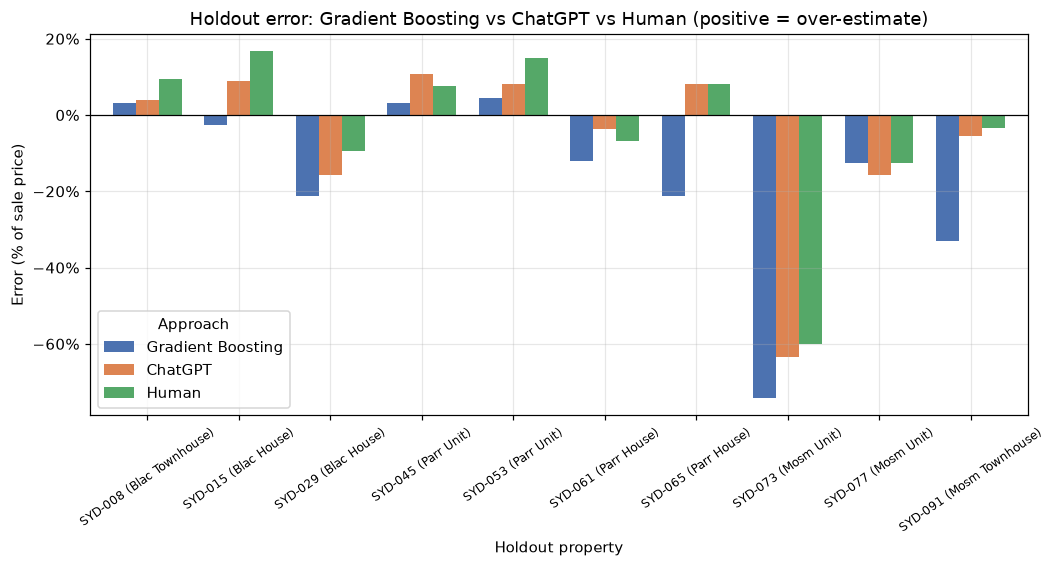

In [26]:
plot_data = pct_errors.copy()
plot_data.index = comp["property_id"] + " (" + comp["suburb"].str[:4] + " " + comp["property_type"] + ")"

fig, ax = plt.subplots(figsize=(11, 4.5))
plot_data.plot(kind="bar", ax=ax, width=0.75, color=["#4c72b0", "#dd8452", "#55a868"])
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Holdout error: Gradient Boosting vs ChatGPT vs Human (positive = over-estimate)",
       xlabel="Holdout property", ylabel="Error (% of sale price)")
ax.tick_params(axis="x", rotation=35, labelsize=8)
ax.legend(title="Approach")
save(fig, "14_holdout_comparison")
plt.show()

**Discussion**

- **Overall:** Human had the lowest MAE ($370,500) and RMSE, and ChatGPT had the lowest MdAPE (8.5%, vs 9.4% for Human and 12.3% for Gradient Boosting). Human and ChatGPT each had 6 of 10 estimates within 10%, compared with 4 for Gradient Boosting.
- **SYD-073 dominates the averages.** All three badly under-estimated this $4.5M Mosman unit (Gradient Boosting −74%, ChatGPT −63%, Human −60%). The most expensive Mosman unit in the development data sold for $2.6M. I kept SYD-073 because it is a genuine sale; it shows that important value information is missing from the structured features, such as exact micro-location, view, aspect, floor level, condition, renovation quality or architecture (I have no source confirming which of these applies). Without it, MAE is $111,667 (Human), $115,000 (ChatGPT) and $216,000 (Gradient Boosting).
- **Gradient Boosting did well on typical properties.** Both Parramatta units, the Blacktown townhouse and house SYD-015 were within about 4%, while the other two approaches over-estimated them by 4–17%.
- **It did poorly on unusual properties:** the 1,182 m² Blacktown block (−21%), Parramatta houses without building area (−12% and −21%) and the Mosman townhouse (−33%). The Human estimate was closest on the large block, both Mosman units and the townhouse.

**Conclusion:** with only 10 properties and one extreme sale, this comparison is **illustrative, not conclusive**, and it does not show that LLM-based estimators are generally better than machine learning. The approaches seem to complement each other: the model is consistent on typical properties, while human market knowledge helps on unusual ones.

## 11. Streamlit Application

With evaluation finished, I retrain the Gradient Boosting Regressor on all 105 properties and save it for the app. The performance figures above stay as the honest estimate of accuracy. No prediction interval is saved, because I did not validate one.

In [27]:
final_model = sklearn.base.clone(selected_model).fit(raw[MODEL_INPUTS], raw[TARGET])

# Typical accessibility values per suburb, used as defaults in the app.
access_defaults = raw.groupby("suburb")[["distance_to_nearest_train_station_km", "distance_to_nearest_bus_route_m",
                                         "regular_bus_routes_within_500m"]].median().round(2)

input_ranges = {}
for col in MODEL_INPUTS:
    if col not in MODEL_CATEGORICAL:
        input_ranges[col] = (float(raw[col].min()), float(raw[col].max()))

bundle = {
    "model": final_model,
    "model_name": selected_name,
    "inputs": MODEL_INPUTS,
    "trained_on_rows": len(raw),
    "suburb_access_defaults": access_defaults.to_dict(orient="index"),
    "ranges": input_ranges,
    "segment_counts": raw.groupby(["suburb", "property_type"]).size().to_dict(),
}
MODEL_PATH = ROOT / "models" / "gradient_boosting_model.joblib"
MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(bundle, MODEL_PATH)

final_metrics = {
    "model_name": selected_name,
    "cv_primary_split": comparison.loc[selected_name].to_dict(),
    "cv_repeated_splits": repeated.loc[selected_name].astype(float).to_dict(),
    "final_holdout": holdout_metrics,
    "mosman_house_oof_mdape": segment_error.loc[("Mosman", "House"), "MdAPE"],
}
with open(ROOT / "report" / "final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2, default=float)

print("Saved", MODEL_PATH.name, "and final_metrics.json")

Saved gradient_boosting_model.joblib and final_metrics.json


**The app** (`app/app.py`) loads the saved model, so it uses exactly the same preprocessing as this notebook.
- **Inputs:** suburb, property type, bedrooms, bathrooms, car spaces, land size and building area. Sizes can be marked unknown. Accessibility values default to the suburb's typical values.
- **Output:** the estimated price with "Model estimate — not a professional property valuation", the suburb median, the property-type median, and the difference from the suburb median.
- **Also shown:** three charts, model performance, limitations, and a CSV upload for several properties.

Run it from the project root:
```bash
source .venv/bin/activate
python -m streamlit run app/app.py
```

## 12. Limitations, Ethics and Conclusion

**Limitations**
- Only 105 sales from three suburbs over about one year, so the model does not generalise to other suburbs or later markets.
- Very few luxury houses (13 in Mosman) and townhouses (4 in total).
- Building area is missing for 33 of 48 houses, and views, condition and renovations are not recorded.
- 30 sales could not be matched on the individual listing page.
- Distances to the CBD and train stations mostly act as suburb labels.
- The 10-property holdout is too small to be conclusive.

**Ethics**
- A model trained on past prices copies existing price gaps between areas, and its errors are much larger for some segments, so it is not equally reliable for everyone.
- A single number can anchor buyers and sellers, so the app shows a clear disclaimer and no unvalidated confidence interval.
- Addresses are not used as model inputs. The tool should support, not replace, a professional valuation.

**Improvements:** more suburbs and years from verified NSW Valuer General data, consistent floor-area data, listing descriptions and condition information, spatial cross-validation and validated prediction intervals.

**Conclusion:** The workflow kept the holdout separate, did all preprocessing inside cross-validated pipelines, compared three models with a baseline, examined the largest errors and ended with a working Streamlit prototype. Gradient Boosting was selected for the final prototype using the repeated-cross-validation mean-MAE criterion, but the gains were small, rankings changed across metrics and the model overfits. The main lesson is that missing information, especially for expensive Mosman houses, limits accuracy more than the choice of algorithm.

In [28]:
assert file_sha256(DATA_PATH) == EXPECTED_SHA256
print("Dataset unchanged:", file_sha256(DATA_PATH))

Dataset unchanged: 0253162a2587e654cb30fcb4b47f1501034353cb2f94941ff3c29540982283ea
